<div class="list-group" id="list-tab" role="tablist">
<h1 class="list-group-item list-group-item-action active" data-toggle="list" style='background:#005097; border:0' role="tab" aria-controls="home"><center>APRENDIZADO DE MÁQUINA (CIC1205/GCC1932) - Trabalho 2</center></h1>

- Nome completo: <João Pedro Jendiroba Paixão Corrêa>
- [Link para vídeo](<https://www.youtube.com/watch?v=hN-K-voHV9k>)

# (5) Predição Conforme (2 pts)

## 5.1 Separação treino / calibração / teste



In [ ]:
# Divisão 60% treino | 20% calibração | 20% teste
# val_size=0.2 dentro de split_train_test_val faz:
#   val_relative = 0.2 / (1 - 0.2) = 0.25  →  25% dos 80% restantes = 20% do total
dataset_cp = DiamondsDataset(diamonds, target_column='price')
dataset_cp.split_train_test_val(test_size=0.2, val_size=0.2, random_state=42)
dataset_cp.preprocess()

X_train_cp, X_cal, X_test_cp, y_train_cp, y_cal, y_test_cp = dataset_cp.get_train_val_test()

total = X_train_cp.shape[0] + X_cal.shape[0] + X_test_cp.shape[0]

print(f'Treino:     {X_train_cp.shape[0]:>6} amostras ({X_train_cp.shape[0]/total:.0%})')
print(f'Calibração: {X_cal.shape[0]:>6} amostras ({X_cal.shape[0]/total:.0%})')
print(f'Teste:      {X_test_cp.shape[0]:>6} amostras ({X_test_cp.shape[0]/total:.0%})')
print(f'Total:      {total:>6} amostras')

Treino:      32349 amostras (60%)
Calibração:  10784 amostras (20%)
Teste:       10784 amostras (20%)
Total:       53917 amostras


## 5.2 Modelo base — GradientBoostingRegressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

gbr = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=5, random_state=42)
gbr.fit(X_train_cp, y_train_cp)

# Avaliacao no conjunto de teste (escala de preco real)
y_pred_log = gbr.predict(X_test_cp)
y_test_price = dataset_cp.inverse_transform_target(y_test_cp)
y_pred_price = dataset_cp.inverse_transform_target(y_pred_log)

print(f'MAE  (R$): {mean_absolute_error(y_test_price, y_pred_price):,.2f}')
print(f'RMSE (R$): {mean_squared_error(y_test_price, y_pred_price)**0.5:,.2f}')
print(f'R²:         {r2_score(y_test_price, y_pred_price):.4f}')

MAE  (R$): 32.47
RMSE (R$): 64.85
R²:         0.9997


## 5.3 Intervalos de predição conformes (cobertura nominal 90 %)

Com o modelo treinado, seguimos três passos:

1. **Scores de não-conformidade** no conjunto de calibração
2. **Quantil de calibração** ajustado para cobertura finita
3. **Intervalo para cada ponto de teste**

In [ ]:
import numpy as np

alpha = 0.10  # cobertura nominal de 90%

# --- Passo 1: scores no conjunto de calibracao (escala log1p) ---
cal_preds = gbr.predict(X_cal)
scores = np.abs(y_cal.values - cal_preds) # residuos absolutos no conjunto de calibração, usados para definir a largura dos intervalos de predição

# --- Passo 2: quantil com correcao de cobertura finita ---
n = len(scores)                                # número de amostras no conjunto de calibração
level = np.ceil((n + 1) * (1 - alpha)) / n     # correção de cobertura finita: quantil é calculado para um nível ligeiramente maior que 1 - alpha, dependendo do tamanho de n
level = min(level, 1.0)                        # o nível não pode ser maior que 1, mesmo para amostras pequenas
q = np.quantile(scores, level)                 # quantil dos scores para o nível ajustado, que define a largura dos intervalos de predição
print(f'n calibracao = {n}')       
print(f'nivel ajustado = {level:.6f}')
print(f'q (log1p) = {q:.6f}')

# --- Passo 3: intervalos no conjunto de teste, convertidos para escala de preco ---
test_preds_log = gbr.predict(X_test_cp)
lower_log = test_preds_log - q
upper_log = test_preds_log + q

lower_price = dataset_cp.inverse_transform_target(lower_log)
upper_price = dataset_cp.inverse_transform_target(upper_log)
pred_price  = dataset_cp.inverse_transform_target(test_preds_log)
y_test_price_arr = dataset_cp.inverse_transform_target(y_test_cp.values)

# --- Cobertura empirica ---
covered = (y_test_price_arr >= lower_price) & (y_test_price_arr <= upper_price)
empirical_coverage = covered.mean()
avg_width = (upper_price - lower_price).mean()

print(f'Cobertura nominal:  {1 - alpha:.0%}')
print(f'Cobertura empirica: {empirical_coverage:.2%}')
print(f'Largura media do intervalo: R$ {avg_width:,.2f}')

n calibracao = 10784
nivel ajustado = 0.900130
q (log1p) = 0.033889
Cobertura nominal:  90%
Cobertura empirica: 90.12%
Largura media do intervalo: R$ 265.04


### Visualização dos intervalos no conjunto de teste

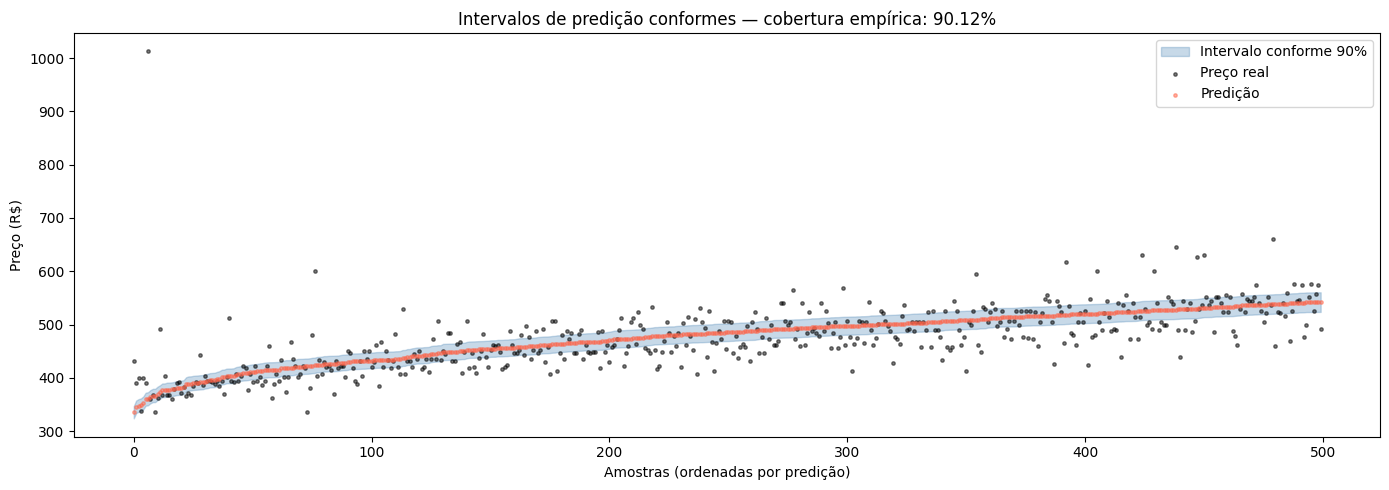

In [ ]:
import matplotlib.pyplot as plt

sample_idx = np.argsort(pred_price)[:500]  # 500 menores predicoes

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(
    range(len(sample_idx)),
    lower_price[sample_idx],
    upper_price[sample_idx],
    alpha=0.3, color='steelblue', label='Intervalo conforme 90%'
)
ax.scatter(range(len(sample_idx)), y_test_price_arr[sample_idx],
           s=6, color='black', alpha=0.5, label='Preço real')
ax.scatter(range(len(sample_idx)), pred_price[sample_idx],
           s=6, color='tomato', alpha=0.5, label='Predição')

ax.set_xlabel('Amostras (ordenadas por predição)')
ax.set_ylabel('Preço (R$)')
ax.set_title(
    f'Intervalos de predição conformes — cobertura empírica: {empirical_coverage:.2%}'
)
ax.legend()
plt.tight_layout()
plt.show()

## 5.4 Exemplos: intervalos mais estreitos e mais largos

In [ ]:
# Largura de cada intervalo (escala de preco)
widths = upper_price - lower_price

# 3 mais estreitos e 3 mais largos
n_exemplos = 3
idx_estreitos = np.argsort(widths)[:n_exemplos]
idx_largos    = np.argsort(widths)[-n_exemplos:][::-1]

def tabela_exemplos(indices, label):
    rows = []
    for i in indices:
        rows.append({
            'preco_real (R$)':    round(y_test_price_arr[i], 2),
            'predicao (R$)':      round(pred_price[i], 2),
            'lower (R$)':         round(lower_price[i], 2),
            'upper (R$)':         round(upper_price[i], 2),
            'largura (R$)':       round(widths[i], 2),
            'coberto':            bool(covered[i]),
        })
    df = pd.DataFrame(rows)
    print(f'--- {label} ---')
    display(df)

tabela_exemplos(idx_estreitos, f'{n_exemplos} intervalos mais estreitos')
tabela_exemplos(idx_largos,    f'{n_exemplos} intervalos mais largos')

--- 3 intervalos mais estreitos ---


,preco_real (R$),predicao (R$),lower (R$),upper (R$),largura (R$),coberto
0,432.0,335.17,323.97,346.76,22.79,False
1,390.0,345.33,333.79,357.27,23.48,False
2,400.0,347.97,336.35,360.00,23.66,False


--- 3 intervalos mais largos ---


,preco_real (R$),predicao (R$),lower (R$),upper (R$),largura (R$),coberto
0,18787.0,18660.05,18038.24,19303.29,1265.06,True
1,18766.0,18657.79,18036.05,19300.96,1264.90,True
2,18757.0,18651.77,18030.24,19294.73,1264.49,True
